In [133]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [134]:
monsoon_flow = np.random.lognormal(mean=4, sigma=1, size = 10000)
# actual discharge, sensor data

# Lognormal Mean (exp(mu + sigma^2/2))
actual_mean = monsoon_flow.mean()
actual_std = monsoon_flow.std()

# median of log normal distro
# mean>median cuz of long right tail
#e_mean = np.exp(4)

#dif = actual_mean - e_mean
#print(f"{actual_mean} - {e_mean} = {dif}")

norm_monsoon_flow = np.random.normal(loc=actual_mean, scale=actual_std, size=10000)

recovery = np.log(monsoon_flow)



print(f"Recovered Mean (Should be ~4): {recovery.mean():.0f}")
print(f"Recovered Std (Should be ~1): {recovery.std():.0f}")

print(monsoon_flow) # for physics/reality
print(recovery) # for math

# so we have the data, we take np.log to calc mu and sigma for our log normal model and get the distro



Recovered Mean (Should be ~4): 4
Recovered Std (Should be ~1): 1
[ 89.7218342   47.54780846 104.34352054 ...  26.96887103  89.63676621
 103.99974566]
[4.49671415 3.8617357  4.64768854 ... 3.29468328 4.49576557 4.64438845]


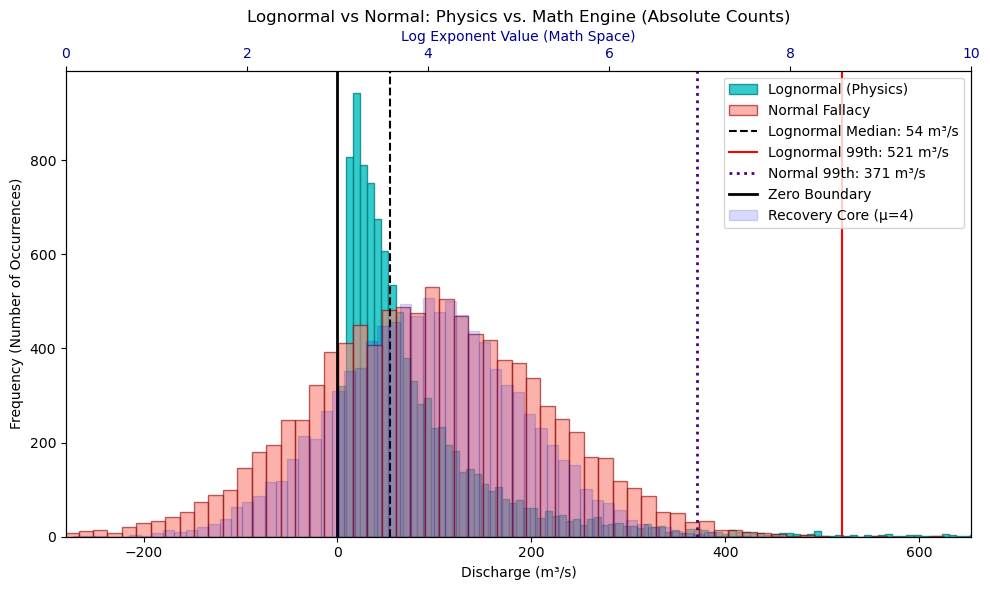

Probability of Cofferdam Failure: 1.06%


In [135]:
# if we use normal, we are assuming additive risk but risks are multiplicative
# use case: to model strictly +ve var with extremely 'black swan' right tails
# like river discharge or cost overruns

# underlying distro is normal, we use log(mu) and log(sigma) OF that normal

monsoon_flow = np.random.lognormal(mean=4, sigma=1, size = 10000)
# actual median flow = exp(4) = ~55

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- PRIMARY AXIS (PHYSICAL REALITY: m³/s) ---
# Procedural Variation: Removed density=True to plot absolute counts (Frequency).
# This prevents the massive scaling distortion.
ax1.hist(monsoon_flow, bins='fd', density=False, alpha=0.8, color='c', edgecolor='teal', label='Lognormal (Physics)')
ax1.hist(norm_monsoon_flow, bins='fd', density=False, alpha=0.6, color='salmon', edgecolor='darkred', label='Normal Fallacy')

ax1.axvline(np.median(monsoon_flow), color='k', linestyle='dashed', label=f"Lognormal Median: {np.median(monsoon_flow):.0f} m³/s") #type:ignore
ax1.axvline(np.percentile(monsoon_flow, 99), color='r', linestyle='solid', label=f"Lognormal 99th: {np.percentile(monsoon_flow, 99):.0f} m³/s") #type:ignore
ax1.axvline(np.percentile(norm_monsoon_flow, 99), color='indigo', linestyle=':', linewidth=2, label=f"Normal 99th: {np.percentile(norm_monsoon_flow, 99):.0f} m³/s") #type:ignore

ax1.set_xlabel("Discharge (m³/s)")
ax1.set_ylabel("Frequency (Number of Occurrences)")
ax1.axvline(0, color='black', linewidth=2, label="Zero Boundary")

# Limit the primary axis to the "Interesting" risk zone, throwing away extreme noise
ax1.set_xlim(np.percentile(norm_monsoon_flow, 0.1), np.percentile(monsoon_flow, 99.5))

# --- SECONDARY AXIS (MATHEMATICAL ENGINE: Log Scale) ---
ax2 = ax1.twiny()
# Also remove density=True here so it aligns in logic (absolute counts).
ax2.hist(recovery, bins='fd', density=False, alpha=0.15, color='blue', edgecolor='darkblue', label='Recovery Core (\u03BC=4)')
ax2.set_xlabel("Log Exponent Value (Math Space)", color='darkblue')
ax2.tick_params(axis='x', labelcolor='darkblue')

# Let's auto-scale the X for the math engine to keep it tidy
ax2.set_xlim(0, 10)

# Combine Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title("Lognormal vs Normal: Physics vs. Math Engine (Absolute Counts)")
plt.tight_layout()
plt.show()

# for a temp cofferdam that is overtopped if q>500
pro_overtop = (monsoon_flow>500).mean() * 100
print(f"Probability of Cofferdam Failure: {pro_overtop:.2f}%")

In [136]:
cost_overrun = np.random.lognormal(mean=0.2, sigma=0.5, size=10000)
# probab that costoverrun is greater than 2, double the estimate

probab_overrun = (cost_overrun>=2).mean() * 100
print(probab_overrun)


16.12


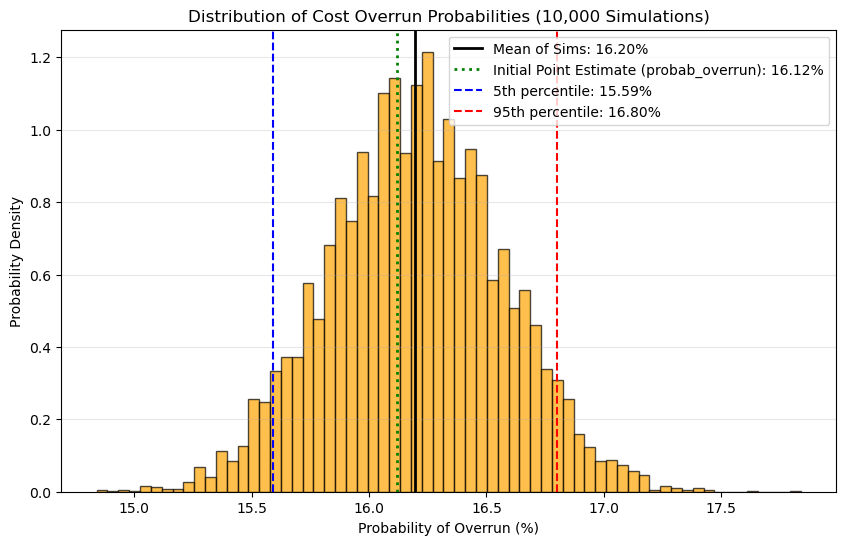

Initial Point Estimate (Cell 3): 16.12%
Mean of 10k Simulations: 16.20%
95% Credible Interval: [15.59%, 16.80%]


In [137]:
# Scientific Intent: Modeling the 'Uncertainty of Uncertainty'

# This proves whether the 'probab_overrun' was representative or just a lucky sample.

n_sims = 10000
n_samples_per_sim = 10000
threshold = 2.0

# Vectorized simulation: 10,000 runs of 10,000 project samples each
sim_data = np.random.lognormal(mean=0.2, sigma=0.5, size=(n_sims, n_samples_per_sim))

# Calculating the probability of overrun for EACH simulation
prob_overrun_dist = (sim_data >= threshold).mean(axis=1) * 100

# Procedural Variation: Visualizing the variability of our risk estimate
plt.figure(figsize=(10, 6))
plt.hist(prob_overrun_dist, bins='fd', density=True, color='orange', alpha=0.7, edgecolor='black')

# Forensics: Adding Mean, Credible Intervals, and the Initial Point Estimate logic
mu_prob = prob_overrun_dist.mean()
p5, p95 = np.percentile(prob_overrun_dist, [5, 95])

plt.axvline(mu_prob, color='black', linestyle='solid', linewidth=2, label=f'Mean of Sims: {mu_prob:.2f}%')
plt.axvline(probab_overrun, color='green', linestyle=':', linewidth=2, label=f'Initial Point Estimate (probab_overrun): {probab_overrun:.2f}%')
plt.axvline(p5, color='blue', linestyle='--', label=f'5th percentile: {p5:.2f}%')
plt.axvline(p95, color='red', linestyle='--', label=f'95th percentile: {p95:.2f}%')

plt.title("Distribution of Cost Overrun Probabilities (10,000 Simulations)")
plt.xlabel("Probability of Overrun (%)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Initial Point Estimate (Cell 3): {probab_overrun:.2f}%")
print(f"Mean of 10k Simulations: {mu_prob:.2f}%")
print(f"95% Credible Interval: [{p5:.2f}%, {p95:.2f}%]")